# 02 Beta 系数估计

本 Notebook 完成：
- 全样本 CAPM 回归（$\alpha, \beta, R^2$）
- 回归残差检验（Ljung-Box 与 White）
- 分年度 Beta 估计
- 60 日滚动 Beta 估计与事件标注

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_white

plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

def setup_chinese_font():
    candidates = ['PingFang SC', 'Heiti SC', 'STHeiti', 'Songti SC', 'Arial Unicode MS', 'Noto Sans CJK SC', 'WenQuanYi Zen Hei', 'SimHei', 'Microsoft YaHei']
    installed = {f.name for f in font_manager.fontManager.ttflist}
    available = [name for name in candidates if name in installed]
    if available:
        plt.rcParams['font.sans-serif'] = available + ['DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False

setup_chinese_font()

In [5]:
BASE_DIR = Path.cwd()
CLEAN_DIR = BASE_DIR / 'data_clean'
OUT_DIR = BASE_DIR / 'output'

log_returns = pd.read_csv(CLEAN_DIR / 'log_returns.csv', index_col=0, parse_dates=True)
stock_meta = pd.read_csv(CLEAN_DIR / 'stock_meta.csv', dtype={'symbol': str, 'name': str, 'industry': str})
rf_df = pd.read_csv(CLEAN_DIR / 'risk_free_rate.csv')

RISK_FREE_DAILY = float(rf_df.loc[0, 'risk_free_daily'])
stock_cols = stock_meta['symbol'].str.zfill(6).tolist()

if len(stock_cols) != 5:
    raise ValueError('stock_meta.csv 中股票数量应为 5。')
if 'HS300' not in log_returns.columns:
    raise ValueError('log_returns.csv 缺少 HS300 列。')

excess = log_returns.copy()
for col in log_returns.columns:
    excess[col] = log_returns[col] - RISK_FREE_DAILY

excess.head()

,600036,600519,002475,600276,601088,HS300
date,,,,,,
2019-01-03,0.010996,-0.014125,-0.049447,-0.036280,-0.003023,-0.001683
2019-01-04,0.022175,0.018601,-0.017876,0.061560,0.013714,0.023576
2019-01-07,0.000168,0.005275,0.036558,-0.014423,-0.000821,0.005953
2019-01-08,-0.010586,-0.001175,0.014188,0.007456,0.013179,-0.002262
2019-01-09,0.016697,0.017167,0.005566,0.027958,0.001682,0.009950


In [3]:
def capm_ols(y: pd.Series, x: pd.Series):
    data = pd.concat([y, x], axis=1).dropna()
    yv = data.iloc[:, 0]
    xv = sm.add_constant(data.iloc[:, 1])
    model = sm.OLS(yv, xv).fit()
    return model

In [6]:
capm_rows = []
diag_rows = []

for symbol in stock_cols:
    model = capm_ols(excess[symbol], excess['HS300'])
    capm_rows.append({
        'symbol': symbol,
        'alpha': model.params['const'],
        'alpha_pvalue': model.pvalues['const'],
        'beta': model.params['HS300'],
        'beta_std_err': model.bse['HS300'],
        'beta_tvalue': model.tvalues['HS300'],
        'beta_pvalue': model.pvalues['HS300'],
        'r_squared': model.rsquared,
        'adj_r_squared': model.rsquared_adj,
        'n_obs': int(model.nobs)
    })

    lb = acorr_ljungbox(model.resid, lags=[10], return_df=True)
    white_stat, white_pvalue, white_fstat, white_fpvalue = het_white(model.resid, model.model.exog)
    diag_rows.append({
        'symbol': symbol,
        'ljungbox_lag10_stat': float(lb['lb_stat'].iloc[0]),
        'ljungbox_lag10_pvalue': float(lb['lb_pvalue'].iloc[0]),
        'white_lm_stat': float(white_stat),
        'white_lm_pvalue': float(white_pvalue),
        'white_f_stat': float(white_fstat),
        'white_f_pvalue': float(white_fpvalue)
    })

capm_table = pd.DataFrame(capm_rows).sort_values('symbol').reset_index(drop=True)
diag_table = pd.DataFrame(diag_rows).sort_values('symbol').reset_index(drop=True)

capm_table.to_csv(OUT_DIR / 'full_sample_capm.csv', index=False, encoding='utf-8-sig')
diag_table.to_csv(OUT_DIR / 'residual_diagnostic_tests.csv', index=False, encoding='utf-8-sig')

capm_table

,symbol,alpha,alpha_pvalue,beta,beta_std_err,beta_tvalue,beta_pvalue,r_squared,adj_r_squared,n_obs
0,002475,0.000751,0.182254,1.336789,0.046752,28.593424,1.020564e-147,0.319795,0.319404,1741
1,600036,0.000178,0.519184,0.757067,0.022947,32.992458,8.594525e-186,0.384970,0.384616,1741
2,600276,0.000098,0.815557,0.891975,0.034831,25.608570,5.350216e-123,0.273843,0.273425,1741
3,600519,0.000325,0.274909,0.910759,0.024731,36.827001,5.543964e-220,0.438167,0.437844,1741
4,601088,0.000411,0.123369,0.294381,0.022133,13.300648,1.631175e-38,0.092336,0.091814,1741


In [7]:
diag_table

,symbol,ljungbox_lag10_stat,ljungbox_lag10_pvalue,white_lm_stat,white_lm_pvalue,white_f_stat,white_f_pvalue
0,002475,5.974873,0.817370,14.776175,6.185779e-04,7.438488,6.070904e-04
1,600036,17.605882,0.061987,71.830055,2.525235e-16,37.396023,1.255600e-16
2,600276,8.606330,0.569826,6.913852,3.152653e-02,3.464728,3.149774e-02
3,600519,9.760038,0.461792,63.469162,1.651378e-14,32.878502,9.650355e-15
4,601088,38.048890,0.000037,4.957161,8.386220e-02,2.481375,8.392442e-02


In [8]:
years = list(range(2019, 2025))
annual_rows = []

for y in years:
    annual_data = excess[excess.index.year == y]
    for symbol in stock_cols:
        reg_data = annual_data[[symbol, 'HS300']].dropna()
        if reg_data.shape[0] < 30:
            annual_rows.append({'year': y, 'symbol': symbol, 'beta': np.nan, 'n_obs': reg_data.shape[0]})
            continue
        model = capm_ols(reg_data[symbol], reg_data['HS300'])
        annual_rows.append({'year': y, 'symbol': symbol, 'beta': model.params['HS300'], 'n_obs': int(model.nobs)})

annual_beta = pd.DataFrame(annual_rows)
annual_beta.to_csv(OUT_DIR / 'annual_beta_2019_2024.csv', index=False, encoding='utf-8-sig')
annual_beta.head()

,year,symbol,beta,n_obs
0,2019,600036,0.778149,243
1,2019,600519,0.966614,243
2,2019,002475,1.421316,243
3,2019,600276,0.861884,243
4,2019,601088,0.460874,243


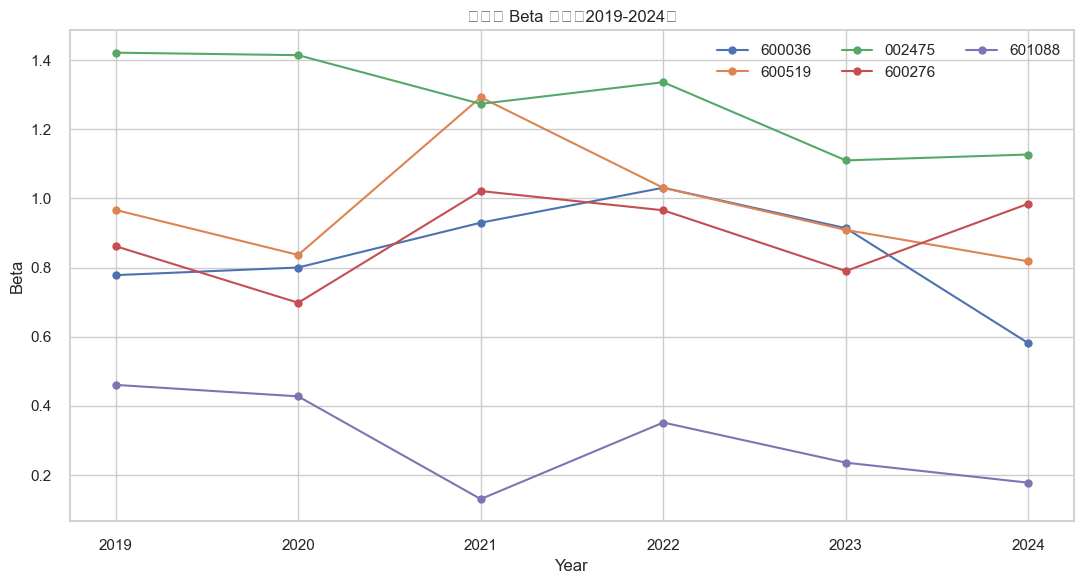

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
for symbol in stock_cols:
    tmp = annual_beta[annual_beta['symbol'] == symbol]
    ax.plot(tmp['year'], tmp['beta'], marker='o', label=symbol)

ax.set_title('分年度 Beta 系数（2019-2024）')
ax.set_xlabel('Year')
ax.set_ylabel('Beta')
ax.legend(ncol=3)
fig.tight_layout()
fig.savefig(OUT_DIR / 'annual_beta_line.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
window = 60
rolling_beta = pd.DataFrame(index=excess.index)
mkt = excess['HS300']

for symbol in stock_cols:
    cov = excess[symbol].rolling(window).cov(mkt)
    var = mkt.rolling(window).var()
    rolling_beta[symbol] = cov / var

rolling_beta.to_csv(OUT_DIR / 'rolling_beta_60d.csv', encoding='utf-8-sig')
rolling_beta.tail()

,600036,600519,002475,600276,601088
date,,,,,
2026-03-20,0.165293,0.563821,1.130577,0.992405,0.035167
2026-03-23,0.284376,0.600729,1.103984,1.040329,0.069063
2026-03-24,0.323848,0.580559,1.055523,1.054217,0.036012
2026-03-25,0.318480,0.562853,1.281815,1.032865,-0.013642
2026-03-26,0.331802,0.574961,1.270649,1.043917,-0.019172


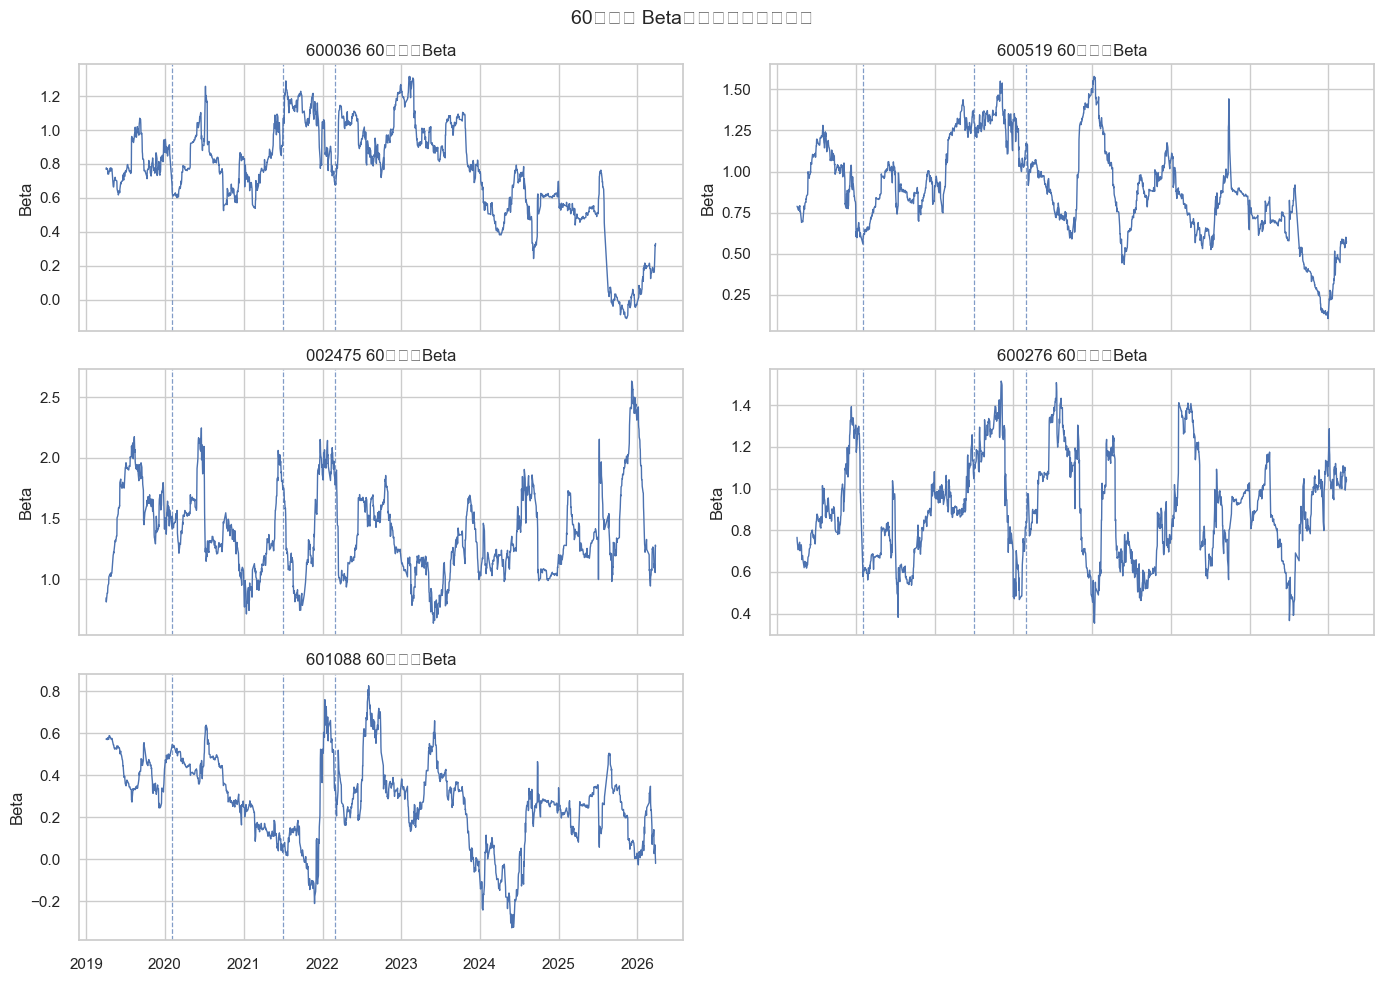

In [11]:
events = {
    'COVID-19冲击': '2020-02-01',
    '监管政策收紧': '2021-07-01',
    'A股大幅调整': '2022-03-01'
}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

for i, symbol in enumerate(stock_cols):
    ax = axes[i]
    ax.plot(rolling_beta.index, rolling_beta[symbol], label=f'{symbol} Rolling Beta', linewidth=1.0)
    for event_name, event_date in events.items():
        ax.axvline(pd.Timestamp(event_date), linestyle='--', linewidth=0.9, alpha=0.7)
    ax.set_title(f'{symbol} 60日滚动Beta')
    ax.set_ylabel('Beta')

for j in range(len(stock_cols), len(axes)):
    axes[j].axis('off')

fig.suptitle('60日滚动 Beta（含关键事件标注）', fontsize=14)
fig.tight_layout()
fig.savefig(OUT_DIR / 'rolling_beta_60d_events.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
stability = rolling_beta.std(skipna=True).reset_index()
stability.columns = ['symbol', 'rolling_beta_std']
stability = stability.sort_values('rolling_beta_std', ascending=False).reset_index(drop=True)
stability.to_csv(OUT_DIR / 'rolling_beta_stability.csv', index=False, encoding='utf-8-sig')
stability

,symbol,rolling_beta_std
0,002475,0.355694
1,600036,0.302087
2,600519,0.287206
3,600276,0.241572
4,601088,0.203259


## 分析建议（填写）

- 根据 `annual_beta_2019_2024.csv` 对比各年份 Beta 变化，重点讨论 2020、2021、2022。
- 根据 `rolling_beta_stability.csv` 说明哪些股票 Beta 最不稳定，并结合行业属性解释。
- 结合 `residual_diagnostic_tests.csv` 讨论模型残差的自相关与异方差特征。